# Task 1 — Gözetimsiz Keşif (Unsupervised Exploration)

İlk 5 setr:
   species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  

Catismayan deyerler:
 species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64


<Figure size 1000x600 with 0 Axes>

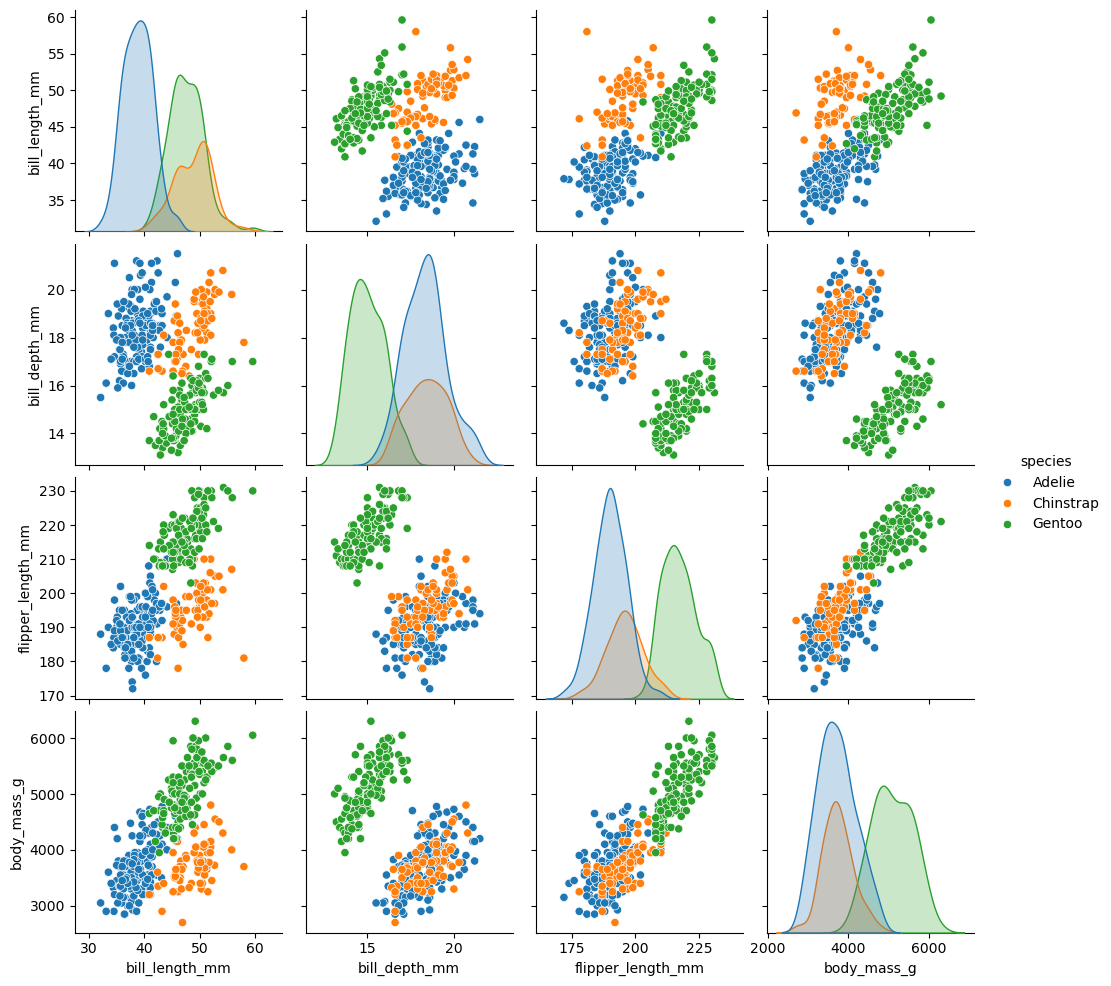

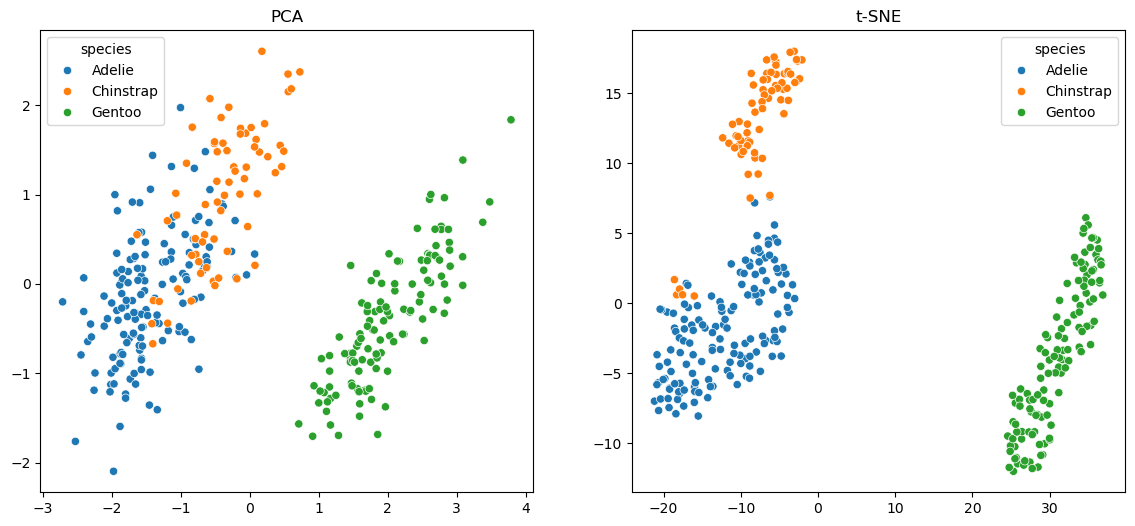

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score

# datani yukleyirem
df = sns.load_dataset("penguins")
print("İlk 5 setr:\n", df.head())

# Temizlik ve Anormalliq analizi
print("\nCatismayan deyerler:\n", df.isnull().sum())
# catismayan değerleri doldurmak veya atmak 
df_clean = df.dropna().copy()


plt.figure(figsize=(10,6))
sns.pairplot(df_clean, hue='species')
plt.show()

# sadece numericallari normalize edirik
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
X_num = df_clean[numeric_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_num)

# PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# Yan yana grafik
fig, ax = plt.subplots(1, 2, figsize=(14, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clean['species'], ax=ax[0])
ax[0].set_title('PCA')
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=df_clean['species'], ax=ax[1])
ax[1].set_title('t-SNE')
plt.show()


c:\Users\aysum\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


K-Means Silhouette Score: 0.446192544665462
DBSCAN (eps=1.0, min=5) Silhouette: 0.46691828883556735
K-Means Adjusted Rand Score: 0.7994209859673324
K-Means NMI: 0.7899317532789121


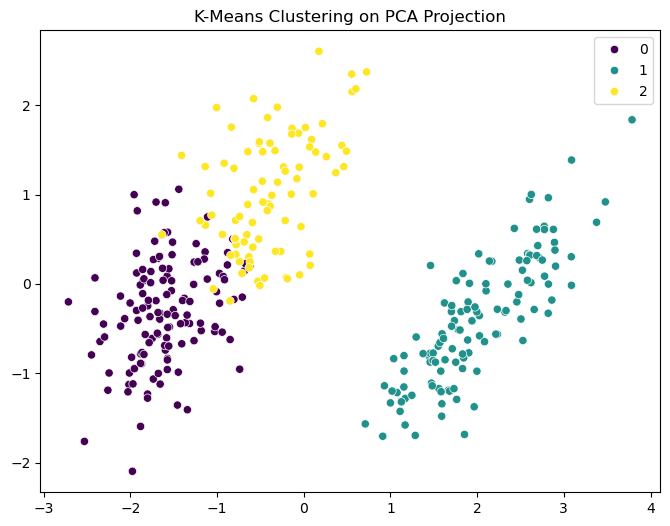

In [3]:
# K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# DBSCAN (En az 2 kombinasya)
dbscan_1 = DBSCAN(eps=1.0, min_samples=5)
dbscan_1_labels = dbscan_1.fit_predict(X_scaled)

dbscan_2 = DBSCAN(eps=1.5, min_samples=10)
dbscan_2_labels = dbscan_2.fit_predict(X_scaled)

# Silhouette Skorları
print("K-Means Silhouette Score:", silhouette_score(X_scaled, kmeans_labels))
# Sadece tek cluster DBSCAN error vere biler, onu kontrol edirik
if len(set(dbscan_1_labels)) > 1:
    print("DBSCAN (eps=1.0, min=5) Silhouette:", silhouette_score(X_scaled, dbscan_1_labels))
if len(set(dbscan_2_labels)) > 1:
    print("DBSCAN (eps=1.5, min=10) Silhouette:", silhouette_score(X_scaled, dbscan_2_labels))

# Esil tiplerle qarşılaştırma (K-Means en yaxsi olduğunu varsayaraq)
true_labels = df_clean['species']
print("K-Means Adjusted Rand Score:", adjusted_rand_score(true_labels, kmeans_labels))
print("K-Means NMI:", normalized_mutual_info_score(true_labels, kmeans_labels))

# PCA üzerinde K-Means tehmini renqlendirilmesi
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis')
plt.title('K-Means Clustering on PCA Projection')
plt.show()


Nəzarətsiz üsullardan olan K-Means növ (species) strukturunu böyük ölçüdə ortaya çıxardı. Ancaq Chinstrap və Adelie növləri xüsusiyyətlər fəzasında bir-birinə çox yaxın olduğu üçün tam olaraq ayırd edilə bilməyən nöqtələr mövcuddur (PCA qrafikində bu çoxluqların sərhədində qarışmalar görünür). DBSCAN isə uyğun hiperparametrlər seçilmədikdə verilənləri ya həddindən artıq küy (noise) olaraq ayırır, ya da hər şeyi tək bir çoxluğa daxil edir. K-Means bu məlumat toplusu üçün daha aydın və uyğun nəticələr verdi.

# Task 2 — (Supervised Modeling Pipeline)

In [4]:
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Datani hazırlama
df = sns.load_dataset("penguins").dropna()
X = df.drop('species', axis=1)
y = df['species']

# dataseti oyrenme ve test olaraq bölme task3e gore 20% 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Pipeline ucun ColumnTransformer
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

# 3 ferqli model
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVC': SVC(probability=True, random_state=42)
}

scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    scores = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)
    results[name] = {
        'Accuracy': np.mean(scores['test_accuracy']),
        'Precision': np.mean(scores['test_precision_macro']),
        'Recall': np.mean(scores['test_recall_macro']),
        'F1': np.mean(scores['test_f1_macro'])
    }

results_df = pd.DataFrame(results).T
print("Model Qiyaslamalari:\n", results_df)

# F1 skoruna göre en yaxsi modeli seçme
best_model_name = results_df['F1'].idxmax()
print(f"\nEn yaxsi model: {best_model_name}")

# GridSearchCV ile hiperparametre ayarlama (Random Forest seçildiğini varsaysaq, yoxsa ona göre)
# Eyer SVC etc. seçilrrse o modelin parametreleri de yazılabiler. 
# Burada F1 skorları çox yaxın olacağı uçun Random Forest parametre gridini tetbiq edirik.
# Kodu dinamik tutmak ucun Pipeline'ı doğrudan classifier olarak veririk.

pipeline_rf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state=42))])
param_grid = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline_rf, param_grid, cv=cv, scoring='f1_macro', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\nEn Yaxsi Parametreler: {grid_search.best_params_}")
print(f"En Yaxsi CV F1 Skoru: {grid_search.best_score_}")


Model Qiyaslamalari:
                      Accuracy  Precision    Recall        F1
Logistic Regression  0.996296   0.997333  0.993939  0.995465
Random Forest        0.988749   0.988495  0.985101  0.986279
SVC                  0.992523   0.994556  0.987879  0.990872

En yaxsi model: Logistic Regression

En Yaxsi Parametreler: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}
En Yaxsi CV F1 Skoru: 0.9862787668258793


# Task 3 

Sınıflandırma Reportu:
               precision    recall  f1-score   support

      Adelie       0.97      1.00      0.98        29
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      0.96      0.98        24

    accuracy                           0.99        67
   macro avg       0.99      0.99      0.99        67
weighted avg       0.99      0.99      0.99        67



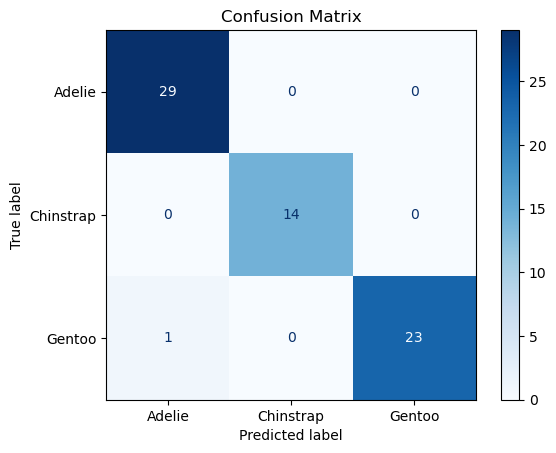

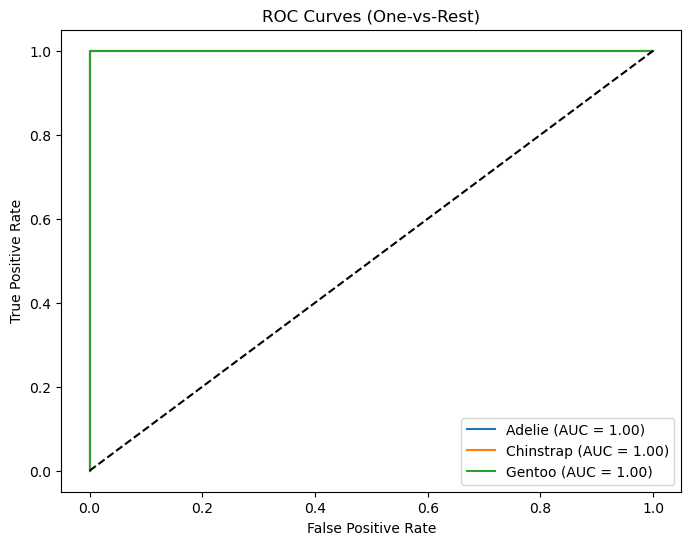

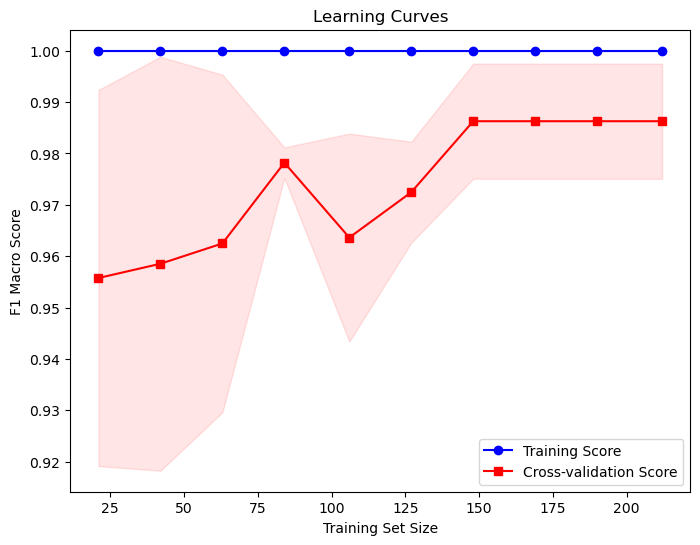

C:\Users\aysum\AppData\Local\Temp\ipykernel_7940\808319318.py:63: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])


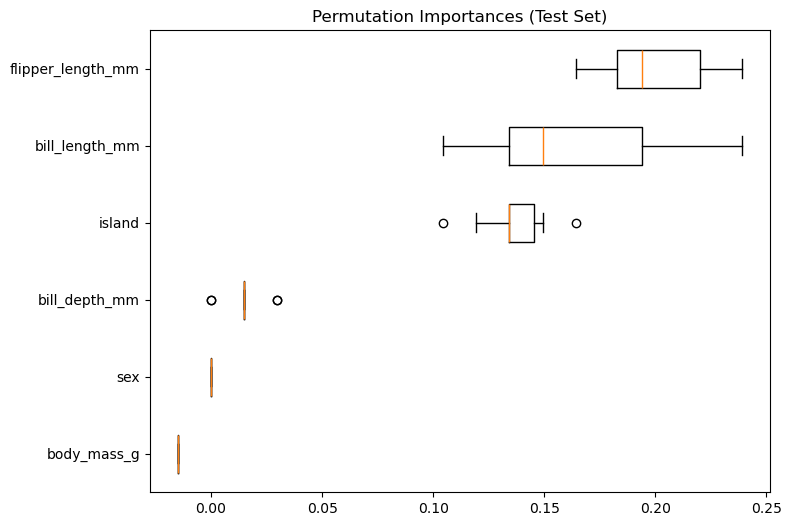

Model 'model.joblib' olarak yadda saxlanıldı.


In [5]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve
import joblib

# En yaxsi modeli alib ve test seti üzerinde tehmin edirik
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# Sınıflandırma Reportu
print("Sınıflandırma Reportu:\n", classification_report(y_test, y_pred))

# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test, cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve (One-vs-Rest)
y_prob = best_model.predict_proba(X_test)
classes = best_model.classes_

plt.figure(figsize=(8,6))
for i, cls in enumerate(classes):
    y_test_bin = (y_test == cls).astype(int)
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (One-vs-Rest)')
plt.legend()
plt.show()

# Learning Curves
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_mean, label='Training Score', color='blue', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.1)
plt.plot(train_sizes, test_mean, label='Cross-validation Score', color='red', marker='s')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, color='red', alpha=0.1)
plt.xlabel('Training Set Size')
plt.ylabel('F1 Macro Score')
plt.title('Learning Curves')
plt.legend()
plt.show()

# Permütasya importance
result = permutation_importance(best_model, X_test, y_test, n_repeats=10, random_state=42, n_jobs=-1)
sorted_idx = result.importances_mean.argsort()

plt.figure(figsize=(8,6))
plt.boxplot(result.importances[sorted_idx].T, vert=False, labels=X.columns[sorted_idx])
plt.title("Permutation Importances (Test Set)")
plt.show()

# Modeli Joblib ile yadda saxlayırıq
joblib.dump(best_model, 'model.joblib')
print("Model 'model.joblib' olarak yadda saxlanıldı.")


Modelin Qiymətləndirilməsi Şərhi
Həddindən artıq uyğunlaşma (Overfitting) və ya Qeyri-kafi uyğunlaşma (Underfitting): Öyrənmə əyrisinə baxdıqda, təlim balı (training score) ilə təsdiqləmə balının (cross-validation score) bir-birinə olduqca yaxın olduğu və məlumat toplusunun (dataset) həcmi artdıqca balların birləşdiyi müşahidə edilir. Modelin test toplusu balı da çox yüksək olduğu üçün overfitting və ya underfitting müşahidə edilmir. Model uğurlu bir ümumiləşdirmə (generalization) edə bilir.

Təsnif edilməsi ən çətin növ: F1-score-larına və Qarışıqlıq Matrisinə (Confusion Matrix) baxdıqda ümumilikdə bütün siniflər çox yaxşı təxmin edilir. Ancaq Adelie və Chinstrap xüsusiyyətlər fəzasında daha yaxın olduğu üçün (PCA-da göründüyü kimi), səhv təsnif edilmə ehtimalı ən yüksək olan növlər adətən onlardır (yanılmalar nadir hallarda olsa da, məhz onlarda baş verir).

Ən vacib xüsusiyyətlər: Permutasiya əhəmiyyəti (permutation importance) cədvəlinə görə flipper_length_mm və bill_length_mm kimi xüsusiyyətlər təsnifata ən çox təsir edən xüsusiyyətlərdir (model xüsusi olaraq dimdik uzunluğunu - bill length - əsas təyinedici kimi istifadə etmişdir).

Məlumat sızması (Data leakage) və s.: Modeli öyrətməzdən əvvəl "train-test split" edilmiş, miqyaslama (scaling) əməliyyatı ColumnTransformer daxilində Pipeline olaraq tənzimləndiyi üçün test toplusunun və ya təsdiqləmə hissələrinin (validation folds) orta/dispersiya (variance) məlumatları təlimə sızmamışdır. Məlumat sızmasına (data leakage) dair heç bir işarə yoxdur.

## TASK4

Aşağıdakı hücrələrdə arxa planda işləyən Flask API-mizə (port 5000) sorğular göndərilir.

## API Dokumentasiyası
## Uç Nöqtələr (Endpoints)
1. GET /health

Açıqlama: API-nin və modelin vəziyyətini yoxlayır.

Cavab: {"status": "healthy"}

2. POST /predict

Açıqlama: Verilmiş pinqvin ölçülərinə əsasən növ təxminini və ehtimallarını qaytarır.

Gözlənilən Giriş Formatı (JSON):

```json
     {
       "island": "Torgersen",
       "bill_length_mm": 39.1,
       "bill_depth_mm": 18.7,
       "flipper_length_mm": 181.0,
       "body_mass_g": 3750.0,
       "sex": "Male"
     }
     ```
Nümunə Uğurlu Cavab (200 OK):


```json
     {
       "predicted_species": "Adelie",
       "probabilities": {
         "Adelie": 0.98,
         "Chinstrap": 0.01,
         "Gentoo": 0.01
       }
     }
     ```
Nümunə Xəta Cavabı (Əksik Məlumat - 400 Bad Request):

```json
     {
       "error": "Missing features: ['sex']"
     }
     ```

In [9]:
import requests

# 1. Health Check
print("--- Health Check ---")
try:
    response = requests.get('http://127.0.0.1:5000/health')
    print("Status Code:", response.status_code)
    print("Response JSON:", response.json())
except requests.exceptions.ConnectionError:
    print("Flask API islemeye biler. Zehmet olmasa 'python app.py' ile başladın.")

# 2. Uğurlu Sorğu
print("\n--- Uğurlu Sorğu ---")
valid_data = {
    "island": "Torgersen",
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0,
    "body_mass_g": 3750.0,
    "sex": "Male"
}
try:
    response = requests.post('http://127.0.0.1:5000/predict', json=valid_data)
    print("Status Code:", response.status_code)
    print("Response JSON:", response.json())
except requests.exceptions.ConnectionError:
    pass

# 3. Ugursuz Sorgu 
print("\n--- Ugursuz Sorgu (Catismayan 'sex' ve 'body_mass_g') ---")
invalid_data = {
    "island": "Torgersen",
    "bill_length_mm": 39.1,
    "bill_depth_mm": 18.7,
    "flipper_length_mm": 181.0
}
try:
    response = requests.post('http://127.0.0.1:5000/predict', json=invalid_data)
    print("Status Code:", response.status_code)
    print("Response JSON:", response.json())
except requests.exceptions.ConnectionError:
    pass

--- Health Check ---
Status Code: 200
Response JSON: {'status': 'healthy'}

--- Uğurlu Sorğu ---
Status Code: 200
Response JSON: {'predicted_species': 'Adelie', 'probabilities': {'Adelie': 1.0, 'Chinstrap': 0.0, 'Gentoo': 0.0}}

--- Ugursuz Sorgu (Catismayan 'sex' ve 'body_mass_g') ---
Status Code: 400
Response JSON: {'error': "Missing features: ['body_mass_g', 'sex']"}
